<a href="https://colab.research.google.com/github/anujv4312-stack/100_days_of_ML/blob/main/column_transformer_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

**column transformer**

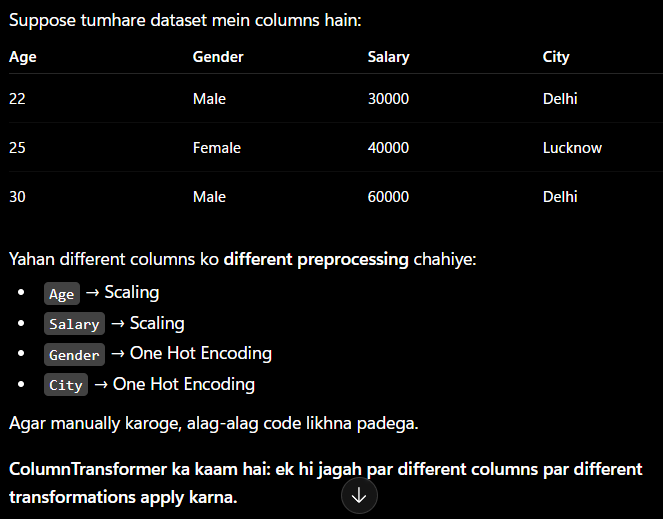

In [3]:
df = pd.read_csv('/content/covid_toy.csv')
df

,age,gender,fever,cough,city,has_covid
0,60,Male,103.0,Mild,Kolkata,No
1,27,Male,100.0,Mild,Delhi,Yes
2,42,Male,101.0,Mild,Delhi,No
3,31,Female,98.0,Mild,Kolkata,No
4,65,Female,101.0,Mild,Mumbai,No
...,...,...,...,...,...,...
95,12,Female,104.0,Mild,Bangalore,No
96,51,Female,101.0,Strong,Kolkata,Yes
97,20,Female,101.0,Mild,Bangalore,No
98,5,Female,98.0,Strong,Mumbai,No


gender aur city me one hot encoding lgega
cough me ordinal
aur fever me simple imputer to remove missing values

In [4]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(df.drop(columns=['has_covid']),df['has_covid'],
                                                test_size=0.2)

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
transformer = ColumnTransformer(transformers = [
    ('trnsf1', SimpleImputer(), ['fever']),
    ('trnsf2', OneHotEncoder(drop='first', sparse_output=False), ['gender', 'city']),
    ('trnsf3', OrdinalEncoder(categories=[['Mild','Strong']]), ['cough'])
], remainder = 'passthrough')

In [13]:
transformer.fit_transform(x_train)

(80, 7)

In [12]:
transformer.fit_transform(x_test)

array([[104.        ,   0.        ,   1.        ,   0.        ,
          0.        ,   1.        ,  75.        ],
       [104.        ,   0.        ,   0.        ,   1.        ,
          0.        ,   0.        ,   6.        ],
       [ 98.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,  64.        ],
       [100.82352941,   0.        ,   0.        ,   0.        ,
          1.        ,   1.        ,  20.        ],
       [104.        ,   1.        ,   0.        ,   0.        ,
          1.        ,   0.        ,  44.        ],
       [ 98.        ,   0.        ,   0.        ,   1.        ,
          0.        ,   0.        ,  31.        ],
       [ 98.        ,   0.        ,   0.        ,   0.        ,
          1.        ,   1.        ,  81.        ],
       [103.        ,   1.        ,   0.        ,   1.        ,
          0.        ,   1.        ,  70.        ],
       [100.82352941,   1.        ,   0.        ,   1.        ,
          0.    